# **Lab 01 - Introduction to Python, Gymnasium and Formulating RL Problem**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
</div>

## Part 1: Getting familiar with Gymnasium

In [1]:
# import Gymnasium library and alias as gym
import gymnasium as gym

In [2]:
total_reward = 0
truncated = False
done = False

In [ ]:
# Create the MountainCar-v0 environment and reset to obtain the initial observation
### YOU NEED TO WRITE YOUR CODE BELOW ###
# HERE 
env = gym.make("MountainCar-v0", render_mode= "human")
observation, _ = env.reset(seed=2026)


d:\Condaa\envs\nt549-05-Tien\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


: 

In [ ]:

while not done and not truncated:

    # Define action by sampling randomly from the environment action space
    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # HERE
    action = env.action_space.sample()

    # Execute the action
    # HERE
    new_obs, reward, done, truncated, info = env.step(action)
    
    total_reward += reward
    observation = new_obs
    env.render()

print("Reward: {}".format(total_reward))
env.close()

## Part 2: Custom Environment "VacuumCleaner"

##### Đặc tả môi trường
1. Phòng kích thước mxn gồm: Robot, bụi, chướng ngại
2. Mục tiêu dọn hết bụi trong phòng
3. Thưởng phạt:
    * Dọn ô bụi: thưởng +1
    * Dọn ô sạch: phạt -0.5
    * Dọn hết bụi trong phòng: thưởng +10 và done
    * Đụng chướng ngại: phạt -10 và truncated
4. Các hàm gymnasium:
    * init: Phòng 5x5, chướng ngại ở (2,2)
        ```python
            def __init__(self, m=5, n=5, obstacle=(2, 2)): 
        ```
        * action_space: 4 hành động lên, xuống, trái, phải
            ```python
                self.action_space = gym.spaces.Discrete(4)
            ```
        * observation_space: robot thấy được vị trí mình trạng thái ma trận
            ```python
                self.observation_space = gym.spaces.Dict({
                    'position': Box(...),
                    'dust': Box(...)
                })
            ``` 
    * reset: Khởi chạy một episode
        * Robot ở (0,0):
            ```python
                self.position = np.array([0,0])
            ```
        * Bụi ở mọi ô còn lại:
            ```python
                self.dust_grid = np.ones((m,n))
            ```
        * Chướng ngại không có bụi:
            ```python
                self.dust_grid[self.obstacle] = 0
            ```
        * Observate bản thân và grid:
            ```python
                obs = {'position': position,'dust': dust_grid}
            ```
    * step: các hành động dẫn đến (state mới, reward)
        * State: vị trí mới, ra ngoài biên chưa?
        * Reward:
            - Kiểm tra chạm chướng ngại
            - Xóa bụi và thưởng
            - Hoàn thành sạch phòng



In [1]:
# Build a simple custom Gymnasium environment named "VacuumCleaner-v0".
# The environment simulates a vacuum robot operating in an m x n room. The robot can
# move up, down, left, and right and automatically vacuums the cell it occupies.
# The objective is to clean all dust particles in the room. There is a single obstacle
# located at a specified cell (i, j) that the robot must avoid. Entering the obstacle
# cell yields a large negative reward and terminates the episode.
# The robot receives a positive reward when it vacuums a dirty cell. If the robot
# attempts to vacuum an already clean cell, that action receives a reduced reward
# (e.g., penalized or halved). When all dust has been cleaned, the agent receives
# a large positive bonus reward and the episode terminates.
# Action space: Discrete(4) -> {0: up, 1: down, 2: left, 3: right}
# Observation space: Dict with 'position' (x, y) and 'dust' grid (m x n binary)

import numpy as np
import os
import time
from IPython.display import clear_output

class VacuumCleanerEnv(gym.Env):
    def __init__(self, m=5, n=5, obstacle=(2, 2)):
        super(VacuumCleanerEnv, self).__init__()
        self.m = m
        self.n = n
        self.obstacle = tuple(obstacle)

        # Action space: 0=up, 1=down, 2=left, 3=right
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.action_space = gym.spaces.Discrete(4)
        # Observation space: position and dust grid
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.observation_space = gym.spaces.Dict({
            'position': gym.spaces.Box(low=0, high=max(self.m,self.n),
                                       shape=(2,), dtype=np.int32),
            'dust': gym.spaces.Box(low=0, high=1,
                                   shape=(self.m,self.n), dtype=np.int8)
        })

        self.reset()

    def reset(self, *, seed=None, options=None):
        # initialize position and dust
        # Start the robot at the top-left corner (row 0, column 0)
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.position = np.array([0,0], dtype=np.int32)

        # Initialize dust grid: 1 indicates dirty, 0 indicates clean.
        # Shape is (m, n) corresponding to the room dimensions.
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.dust_grid = np.ones((self.m,self.n), dtype=np.int8)

        # Ensure the obstacle cell contains no dust (robot cannot clean there).
        # This also prevents rewarding the agent for occupying the obstacle.
        self.dust_grid[self.obstacle] = 0  # obstacle cell has no dust
        self.total_reward = 0.0
        self.truncated = False
        self.terminated = False
        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, {}

    def step(self, action):
        # compute candidate new position
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        if action == 0:   # Up
            candidate = self.position + np.array([-1,0])
        elif action == 1: # Down
            candidate = self.position + np.array([1,0])
        elif action == 2: # Left
            candidate = self.position + np.array([0,-1])
        elif action == 3: # Right
            candidate = self.position + np.array([0,1])
        else:
            candidate = self.position.copy()

        # boundary check
        if (0 <= candidate[0] < self.m) and (0 <= candidate[1] < self.n):
            # obstacle check
            if tuple(candidate) == self.obstacle:
                self.position = candidate.copy()
                reward = -10.0
                self.terminated = True
                obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
                self.total_reward += reward
                return obs, reward, True, False, {}
            else:
                self.position = candidate.copy()
        # else: stay in place

        # If the robot is on a dirty cell, give a positive reward (1.0) and mark it clean.
        # If the cell is already clean, apply a small penalty (-0.5) to discourage redundant cleaning.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        x, y = int(self.position[0]), int(self.position[1])

        if self.dust_grid[x, y] == 1:
            reward = 1.0
            self.dust_grid[x, y] = 0
        else:
            reward = -0.5
                
        self.total_reward += reward

        # check if all cleaned
        if np.sum(self.dust_grid) == 0:
            reward += 10.0
            self.terminated = True

        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, reward, bool(self.terminated), bool(self.truncated), {}

    def render(self, mode='human'):
        # In Jupyter notebooks, use IPython.display.clear_output to clear the cell output.
        try:
            clear_output(wait=True)
        except Exception:
            # Fallback for terminal execution
            os.system('cls' if os.name == 'nt' else 'clear')

        # Build display grid with symbols:
        # '#' obstacle, '.' dirty, ' ' clean, 'R' robot, 'X' robot on obstacle
        display = np.full((self.m, self.n), ' ', dtype='<U1')
        for i in range(self.m):
            for j in range(self.n):
                if (i, j) == self.obstacle:
                    display[i, j] = '#'
                elif self.dust_grid[i, j] == 1:
                    display[i, j] = '.'
                else:
                    display[i, j] = ' '

        x, y = int(self.position[0]), int(self.position[1])
        if (x, y) == self.obstacle:
            display[x, y] = 'X'
        else:
            display[x, y] = 'R'

        for row in display:
            print(''.join(row))
        print(f"Total reward: {self.total_reward}")
        time.sleep(0.15)

NameError: name 'gym' is not defined

##### Các chính sách
1. Random: Ngẫu nhiên chọn 1 trong 4 action
2. Round robin: Đi zigzac, hard-code
3. Priority-based: Đi xoắn ốc từ ngoài vào, hard-code

In [ ]:
def robot_policy(option="random", env=None):
     """
     A simple policy function that selects an action based on the specified option.
     Currently supports only a random policy.
     """
     x, y = env.position
     m, n = env.m, env.n
    # lưu hướng hiện tại của robot
     if not hasattr(env, "direction"):
        env.direction = 3  # start moving right

     if option == "random":
          return env.action_space.sample()  # Randomly select an action from the action space
     
     elif option == "round_robin":
        # hàng chẵn: đi sang phải
        if x % 2 == 0:
            if y < n - 1:
                return 3  # right
            else:
                return 1  # xuống
        # hàng lẻ: đi sang trái
        else:
            if y > 0:
                return 2  # left
            else:
                return 1  # xuống

    
     elif option == "priority":

        # initialize spiral state if chưa có
        if not hasattr(env, "spiral_state"):
            env.spiral_state = {
                "top": 0,
                "bottom": env.m - 1,
                "left": 0,
                "right": env.n - 1,
                "dir": "right"
            }

        x, y = env.position
        s = env.spiral_state

        if s["dir"] == "right":
            if y < s["right"]:
                return 3  # right
            else:
                s["top"] += 1
                s["dir"] = "down"
                return 1

        elif s["dir"] == "down":
            if x < s["bottom"]:
                return 1  # down
            else:
                s["right"] -= 1
                s["dir"] = "left"
                return 2

        elif s["dir"] == "left":
            if y > s["left"]:
                return 2  # left
            else:
                s["bottom"] -= 1
                s["dir"] = "up"
                return 0

        elif s["dir"] == "up":
            if x > s["top"]:
                return 0  # up
            else:
                s["left"] += 1
                s["dir"] = "right"
                return 3
     

##### Hàm thí nghiệm
Có thể thay đổi tên chính sách để quan sát cách chúng thể hiện, nhìn thấy log cho từng chính sách cụ thể.

In [ ]:
if __name__ == "__main__":
    env = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2))
    obs, _ = env.reset()
    env.render()
    terminated = False
    truncated = False

    while not terminated and not truncated:
        action = robot_policy(option="round_robin", env=env)
        obs, reward, terminated, truncated, info = env.step(action)
        env.render()
        print(f"Action: {action}, Reward: {reward}, Terminated: {terminated}")
        if terminated or truncated:
            print("Episode finished with total reward:", env.total_reward)
            break

.    
     
  X..
.....
.....
Total reward: 1.0
Action: 3, Reward: -10.0, Terminated: True
Episode finished with total reward: 1.0


##### Giải thích
Bên dưới là phần chạy hàm các chính sách và vẽ vào cùng một biểu đồ

In [ ]:
import matplotlib.pyplot as plt

def save(policy="random", episodes=100):

    rewards = []

    for ep in range(episodes):

        env = VacuumCleanerEnv(m=5, n=5, obstacle=(2,2))
        obs, _ = env.reset()

        terminated = False
        truncated = False

        while not terminated and not truncated:

            action = robot_policy(option=policy, env=env)

            obs, reward, terminated, truncated, _ = env.step(action)

        rewards.append(env.total_reward)

    return rewards

In [ ]:
random_rewards = save("random",100)
round_rewards = save("round_robin",100)
priority_rewards = save("priority",100)

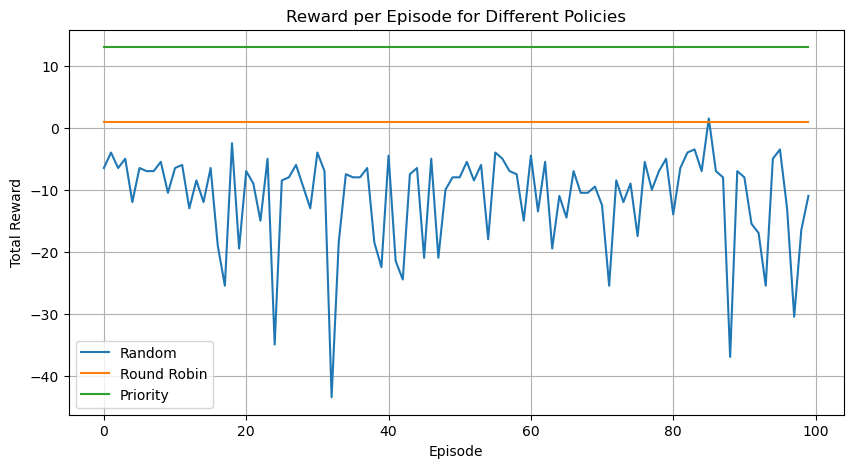

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(random_rewards,label="Random")
plt.plot(round_rewards,label="Round Robin")
plt.plot(priority_rewards,label="Priority")

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward per Episode for Different Policies")

plt.legend()
plt.grid(True)

plt.show()

Evaluation and Analysis

1. Chính sách random:
    * Robot ngẫu nhiên các hành động nên có thể đâm tường, chướng ngại vật hoặc dọn cả ô đã sạch
    * Đồ thị cho thấy dao động reward cao, thiếu ổn định với trung bình các mẫu thấp
2. Chính sách Round Robin:
    * Robot đi theo kiểu zig-zac nhưng do chướng ngại ở ô (2,2) nên nó dừng sớm vì đụng phải chướng ngại vật nên không dọn được nhiều ô và kết thúc với số điểm tương đối thấp (tệ nhất trong cả 3).
    * Đồ thị là hằng vì chính sách là hard-code dựa trên môi trường tĩnh, đạt trung bình mẫu reward 1 (cao thứ 2 trong 3 chính sách)
3. Chính sách Priority-based:
    * Robot di chuyển bám tường và xoắn ốc, vô tình tại môi trường và ô chướng ngại (2,2) tạo điều kiện để nó đi sâu vào trong và dọn hết các ô nên hoàn thành với số điểm cao.
    * Đồ thị là hằng vì chính sách là hard-code theo môi trường tĩnh, đạt trung bình mẫu cao nhất là 13 (cao nhất trong 3 chính sách).


## Part 3: Load Balancing Problem

#### Đặc tả môi trường

##### Các lớp được định nghĩa
1. Class task: gồm task_id để định danh và processing_time là thời gian xử lý
2. Class server: có thể thực hiện 1 task và có hàng đợi queue
    * Số task tối đa trong queue: `self.queue_capacity`
    * Task đang chạy: `self.current_task`
    * Số bước còn lại hoàn thành task đang chạy: `self.remaining_time`
3. Logic server:
    * run_one_step(): cách chạy 1 timestep
        1. Xử lý task đang chạy
            ```py
            if self.current_task is not None:
                self.remaining_time -= 1
            ```
        2. Kiểm tra task hoàn thành
            ```py
            if self.remaining_time <= 0:
            ```
           Nếu hết task server thành idle
        3. FIFO queue
            ```py
            if self.current_task is None and len(self.queue) > 0:
            ```
           Server lấy task từ queue nếu idle
    * add_task(): cách thêm task vào server `def add_task(self, task):`
        1. Server nếu rảnh xử lý ngay -> true
        2. Server nếu không rảnh mà còn queue thì đưa vào cuối queue -> true
        3. Server nếu bận, queue đầy sẽ drop ->false


In [8]:
"""
Load Balancing Environment Simulation

This program simulates a load balancing environment where tasks are distributed among multiple servers. 
Each server has a queue with a limited size, and tasks are processed based on their arrival and the server's availability.

Key Components:
1. Task: Represents a task with a specific processing time.
2. Server: Represents a server that processes tasks. Each server has a queue to hold tasks waiting for processing.
3. LoadBalancingEnv: A custom OpenAI Gym environment that simulates the load balancing scenario. 
     The environment allows agents to decide which server to send a task to, aiming to maximize rewards by minimizing 
     dropped tasks and reducing waiting times.

The goal is to design a load balancing strategy that optimally distributes tasks among servers to maximize efficiency.

Classes:
- Task: Represents a task with a specific processing time.
- Server: Represents a server with a queue of limited size.
- LoadBalancingEnv: Custom Gym environment for the load balancing problem.

Usage:
- The environment can be used to train reinforcement learning agents to learn optimal load balancing strategies.
"""

import random
from collections import deque

class Task:
      """A task with a unique id and required processing time (in time steps)."""

      def __init__(self, task_id: int, processing_time: int):
            self.task_id = task_id  # Unique identifier for tracking
            self.processing_time = processing_time  # Number of steps needed to finish


class Server:
      """
      A server with:
      - one currently running task
      - a waiting queue with finite capacity
      """

      def __init__(self, queue_capacity: int):
            self.queue_capacity = queue_capacity  # Max number of tasks waiting in queue
            self.queue = deque()  # FIFO queue of waiting tasks
            self.current_task = None  # Task being processed right now
            self.remaining_time = 0  # Steps left for current_task

      def run_one_step(self):
            """
            Execute one simulation step on this server.

            Returns:
                  completed_task (Task | None): task completed at this step, if any.
            """
            completed_task = None

            # Process one time unit for currently running task
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.current_task is not None:
                  self.remaining_time -= 1

            if self.remaining_time <= 0:
                  completed_task = self.current_task
                  self.current_task = None
            # If server becomes idle, immediately pull next task from queue
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.current_task is None and len(self.queue) > 0:
                  next_task = self.queue.popleft()
                  self.current_task = next_task
                  self.remaining_time = next_task.processing_time
            return completed_task

      def add_task(self, task: Task) -> bool:
            """
            Try to add a task to this server.

            Rules:
            - If server is idle: start processing immediately.
            - Else if queue has room: enqueue task.
            - Else: reject (drop) task.

            Returns:
                  bool: True if accepted, False if dropped.
            """
            # Start immediately if server is free
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.current_task is None:
                  self.current_task = task
                  self.remaining_time = task.processing_time
                  return True
            # Otherwise enqueue if capacity allows
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if len(self.queue) < self.queue_capacity:
                  self.queue.append(task)
                  return True
            # Queue full -> task dropped
            return False

      def queue_length(self) -> int:
            # Current number of waiting tasks (excluding running task)
            return len(self.queue)

##### Định nghĩa môi trường
1. Agent lựa chọn gán task cho các server với mục tiêu cân bằng tải
2. Thưởng phạt:
    * Hoàn thành task thưởng +2
    * Nhận task được gán +0.5
    * Drop task được gán -5
    * Phạt nếu queue dài `reward -= 0.5 * server.queue_length()`
1. init: Tạo ra 3 server, mỗi server có queue sức chứa là 2
    * Server mang id là 0,1,2 Task mang id là 0,1,2,3...
    * 4 tập thống kê gồm: task đã tạo, được nhận, hoàn thành, bị drop
2. action_space: gồm 3 action là 0,1,2 là id của server được chọn
    ```py
    self.action_space = gym.spaces.Discrete(self.n_servers)
    ```
3. observation_space: state nhìn thấy gồm server và thời gian
    * Server có: remaining_time, queue_length
        * Remaining time: là thời gian task hiện tại còn lại
            ```py
            gym.spaces.Box(low=0, high=10)
            ```
        * Queue length: là độ dài queue đang chứa
            ```py
            gym.spaces.Discrete(queue_capacity + 1)
            ```
    * Time là thời gian simulation (1s/timestep):
        ```py
        "time": gym.spaces.Box(low=0, high=1e6)
        ```
4. new_task(): sinh task mới với id tăng dần, processing_time ngẫu nhiên từ 1-5 rồi đưa vào tập task đã tạo
5. reset(): Khởi chạy lại episode mới bằng cách xóa hết tập thống kê, obeservation, task, server, thời gian, reward,...
6. step: state mới và reward từ lựa chọn action
    * Logic một step mới:
        1. Mỗi server xử lý task hiện tại của nó
        2. Task mới được sinh ra
        3. Agent lựa chọn server xử lý task mới -> action
        4. Reward được tính theo thứ tự hoàn thành, nhận/drop, độ nghẽn hiện tại
    * State mới: trạng thái các server và thời gian
    * Reward:
        * Server hoàn thành task hiện tại
        * Server nhận hoặc drop task mới được gán cho
        * Trạng thái queue của mỗi server
     

In [9]:
class LoadBalancingEnv(gym.Env):
      """
      Custom Gym environment for load balancing.

      Action:
            Choose a server index to receive the new incoming task.

      State:
            - each server's remaining processing time and queue length
            - global time step

      Metrics tracked:
            - total_created_tasks
            - accepted_tasks
            - dropped_tasks
            - completed_tasks
            - drop_rate
      """

      metadata = {"render.modes": ["human"]}

      def __init__(self, n_servers: int = 3, queue_capacity: int = 2, seed: int = None):
            super().__init__()
            self.n_servers = n_servers
            self.queue_capacity = queue_capacity
            self.rng = random.Random(seed)  # Local random generator for reproducibility

            # Create server pool
            self.servers = [Server(queue_capacity) for _ in range(n_servers)]
            self.time = 0  # Global simulation step
            self.total_reward = 0.0  # Accumulated reward over episode

            # Task tracking
            self.next_task_id = 0
            self.tasks_created = {}     # task_id -> Task
            self.tasks_completed = set()  # IDs of completed tasks
            self.tasks_dropped = set()  # IDs of dropped tasks
            self.tasks_accepted = set()  # IDs of accepted tasks

            # RL spaces
            # Define action space with n_servers 
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.action_space = gym.spaces.Discrete(self.n_servers)

            # Define observation space as a dict containing server states and global time
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.observation_space = gym.spaces.Dict({
                  "servers": gym.spaces.Tuple(tuple(
                        gym.spaces.Dict({
                              "remaining_time": gym.spaces.Box(low=0, high=10, shape=(), dtype=float),
                              "queue_length": gym.spaces.Discrete(self.queue_capacity + 1)
                        })
                        for _ in range(self.n_servers)
                  )),
                  "time": gym.spaces.Box(low=0, high=1e6, shape=(), dtype=float)
            })


      def _new_task(self) -> Task:
            """Create one new incoming task with random processing time [1, 5]."""
            # Create a new task with a unique ID and random processing time between 1 and 5
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            t = Task(
                  self.next_task_id,
                  self.rng.randint(1,5)
                  )
            self.tasks_created[t.task_id] = t
            self.next_task_id += 1
            return t

      def reset(self, *, seed=None, options=None):
            """Reset environment state and all tracking metrics."""
            # Optional reseed to make episode deterministic from this point
            if seed is not None:
                  self.rng.seed(seed)

            # Reinitialize server states, time, and rewards
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.servers = [Server(self.queue_capacity) for _ in range(self.n_servers)]
            self.time = 0
            self.total_reward = 0.0
            self.next_task_id = 0
            # Clear all task statistics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.tasks_created = {}
            self.tasks_completed = set()
            self.tasks_dropped = set()
            self.tasks_accepted = set()

            # Gymnasium-style reset return: (observation, info)
            return self._get_observation(), {}

      def step(self, action: int):
            """
            Run one simulation step:
            1) Advance all servers by one time step.
            2) Generate one new task.
            3) Route task to selected server.
            4) Compute reward and return transition tuple.
            """
            reward = 0.0

            # 1) Process running tasks on each server
            # For each server, call run_one_step() to advance processing. If a task completes, add to completed set and give a positive reward (+2.0)
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            for server in self.servers:
                  completed = server.run_one_step()

                  if completed is not None:
                        self.tasks_completed.add(completed.task_id)
                        reward += 2.0

            # 2) Generate one new incoming task
            new_task = self._new_task()

            # 3) Route task based on action (selected server index)
            # Try to add the new task to the selected server. 
            # If accepted, add to accepted set and give a small reward (+0.5). 
            # If dropped, add to dropped set and give a strong penalty (-5.0).
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            
            server = self.servers[action]
            accepted = server.add_task(new_task)

            if accepted:
                  self.tasks_accepted.add(new_task.task_id)
                  reward += 0.5
            else:
                  self.tasks_dropped.add(new_task.task_id)
                  reward -= 5.0
            # 4) Add congestion penalty proportional to queue sizes
            # To encourage the agent to balance load and avoid long queues, subtract a small penalty (e.g., -0.5) for each task waiting in any server's queue.
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            for server in self.servers:
                  reward -= 0.5 * server.queue_length()

            # Update global counters
            self.total_reward += reward
            self.time += 1

            # This environment currently never ends by itself
            terminated = False
            truncated = False
            info = self._get_info()

            return self._get_observation(), reward, terminated, truncated, info

      def _get_observation(self):
            """Build observation dict from current system state."""
            # As a hint to design your observation, we provide the following structure:
            return {
                  "servers": tuple(
                         {
                               "remaining_time": float(server.remaining_time),
                               "queue_length": server.queue_length(),
                         }
                         for server in self.servers
                  ),
                  "time": float(self.time),
            }

      def _get_info(self):
            """Return useful metrics for logging/evaluation."""
            # Compute metrics based on requirements on your lab assignment. Here are some examples:
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            total_created = len(self.tasks_created)
            dropped = len(self.tasks_dropped)
            completed = len(self.tasks_completed)
            accepted = len(self.tasks_accepted)

            # Safe division to avoid divide-by-zero at the beginning
            # Calculate some key performance metrics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            drop_rate = dropped / total_created if total_created > 0 else 0.0
            #...

            return {
                  # Some example info fields: time, dropped tasks, dop_rate, etc.
                  "time": self.time,
                  "total_created": total_created,
                  "accepted": accepted,
                  "dropped": dropped,
                  "completed": completed,
                  "drop_rate": drop_rate
            }

#### Các chính sách
* Random: Ngẫu nhiên chọn bừa các server
* Round robin: Chọn theo kiểu xoay vòng server
* Greedy: Chọn ưu tiên server có queue đang trống nhất
* Epsilon greedy: dựa trên số p với epsilon=0.2
    * Nếu p < epsilon: Chính sách Random
    * Nếu p >= epsilon: Chính sách Greedy

In [10]:
def load_balancing_policy(option="random", env=None):
      """Simple baseline policy."""
      if option == "random":
            # Uniform random server selection
            return env.action_space.sample()
      # Define other policies based on the option string
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE      
      elif option == "round_robin":
            # Select server sequentially
            server_index = env.time % env.n_servers
            return server_index

      elif option == "greedy":
            # Choose server with smallest queue length
            queue_lengths = [s.queue_length() for s in env.servers]
            best_server = queue_lengths.index(min(queue_lengths))
            return best_server

      elif option == "epsilon_greedy":
            epsilon = 0.2
            p = random.random()

            if p < epsilon:
                  # exploration
                  return env.action_space.sample()
            else:
                  # exploitation (same as greedy)
                  queue_lengths = [s.queue_length() for s in env.servers]
                  best_server = queue_lengths.index(min(queue_lengths))
                  return best_server
      raise ValueError(f"Unsupported policy option: {option}")

#### Hàm thí nghiệm
Trả ra một output log có thể xem tình trạng các server

In [21]:
if __name__ == "__main__":
      # Create environment and reset initial state
      env = LoadBalancingEnv(n_servers=3, queue_capacity=2, seed=42)
      obs, info = env.reset()

      # Run fixed number of simulation steps with random policy
      for step in range(20): # 20 episodes = 20 steps = 20 seconds of simulated time = 20 tasks created
            action = load_balancing_policy(option="greedy", env=env)
            obs, reward, terminated, truncated, info = env.step(action)
            
            # Print every value you want to track at each step
            # Save metrics to a csv file for later analysis
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            print(f"\n--- Step {step} ---")
            print(f"Action (server): {action}")
            print(f"Reward: {reward}")
            print(f"Servers state:")
            for i, s in enumerate(env.servers):
                  print(f"  Server {i}: remaining={s.remaining_time}, queue={s.queue_length()}")
      # Print summary statistics after simulation ends.
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE
      print("\n=== Simulation Summary ===")
      print(f"Total reward: {env.total_reward}")
      print(f"Tasks created : {len(env.tasks_created)}")
      print(f"Tasks accepted: {len(env.tasks_accepted)}")
      print(f"Tasks completed: {len(env.tasks_completed)}")
      print(f"Tasks dropped : {len(env.tasks_dropped)}")


--- Step 0 ---
Action (server): 0
Reward: 0.5
Servers state:
  Server 0: remaining=1, queue=0
  Server 1: remaining=0, queue=0
  Server 2: remaining=0, queue=0

--- Step 1 ---
Action (server): 0
Reward: 2.5
Servers state:
  Server 0: remaining=1, queue=0
  Server 1: remaining=0, queue=0
  Server 2: remaining=0, queue=0

--- Step 2 ---
Action (server): 0
Reward: 2.5
Servers state:
  Server 0: remaining=3, queue=0
  Server 1: remaining=0, queue=0
  Server 2: remaining=0, queue=0

--- Step 3 ---
Action (server): 0
Reward: 0.0
Servers state:
  Server 0: remaining=2, queue=1
  Server 1: remaining=0, queue=0
  Server 2: remaining=0, queue=0

--- Step 4 ---
Action (server): 1
Reward: 0.0
Servers state:
  Server 0: remaining=1, queue=1
  Server 1: remaining=2, queue=0
  Server 2: remaining=0, queue=0

--- Step 5 ---
Action (server): 1
Reward: 2.0
Servers state:
  Server 0: remaining=2, queue=0
  Server 1: remaining=1, queue=1
  Server 2: remaining=0, queue=0

--- Step 6 ---
Action (server): 0

#### Giải thích
Bên dưới là hàm ghi nhận, so sánh kết quả các chính sách trên 1 biểu đồ

In [28]:

def save_metrics(policy="random", episodes=100, steps=100):
     rewards = []

     for ep in range(episodes):

        # tạo môi trường mới cho mỗi episode
        env = LoadBalancingEnv(n_servers=3, queue_capacity=2, seed=42)
        obs, _ = env.reset()

        # chạy simulation
        for step in range(steps):

            action = load_balancing_policy(option=policy, env=env)
            obs, reward, terminated, truncated, _ = env.step(action)

        # lưu tổng reward của episode
        rewards.append(env.total_reward)

     return rewards

In [29]:
random_rewards = save_metrics("random",100)
round_rewards = save_metrics("round_robin",100)
greedy_rewards = save_metrics("greedy",100)
epsilon_rewards = save_metrics("epsilon_greedy",100)

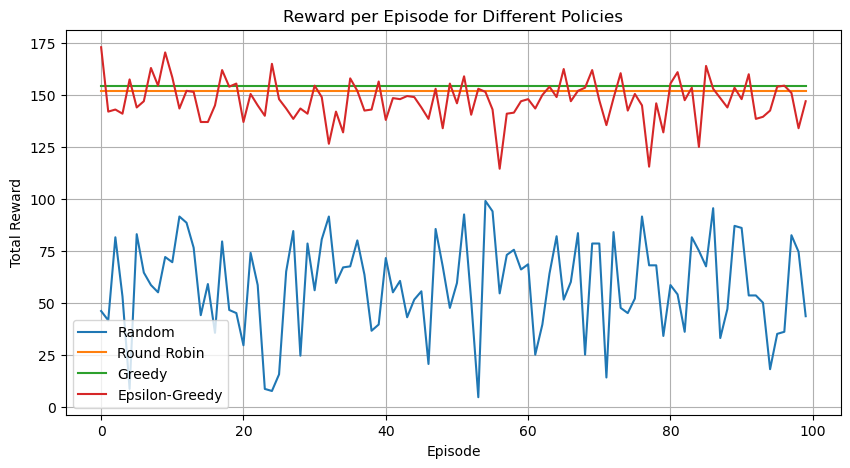

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(random_rewards,label="Random")
plt.plot(round_rewards,label="Round Robin")
plt.plot(greedy_rewards,label="Greedy")
plt.plot(epsilon_rewards,label="Epsilon-Greedy")

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward per Episode for Different Policies")

plt.legend()
plt.grid(True)

plt.show()

Evaluation and Analysis
* Chính sách random cho thấy trung bình mẫu dao động lớn nhưng thấp và tệ nhất trong cả 4 chính sách
* Round Robin và Greedy là 2 chính sách hard-code nên luôn cho đồ thị là hàm hằng, trung bình mẫu của chúng gần tương đương nhau và khoog có dao động
* Epsilon-Greedy cho mẫu dao động nhưng ít đột biến hơn random (vì epsilon đang là 0.2 khá nhỏ). Trung bình mẫu gần bằng với Round Robin và Greedy
* Xét công bằng ở epsilon=0.2, Round Robin và Greedy vẫn ổn định và tốt hơn Random và Episilon-Greedy. Epsilon lớn hơn sẽ dần đưa đồ thị Epislon-Greedy thấp dần về Random, ngược lại epsilon nhỏ hơn sẽ nâng đồ thị Epsilon-Greedy về phía Greedy nhưng trung bình luôn thấp hơn Greedy.

## CONGRATULATIONS TEAM!

Congratulations to the team for completing Part 2,3 of Lab01 - Introduction to Python, Gymnasium and Formulating RL Problem.
Keep up the effort in the next sections.

References: https://gymnasium.farama.org/ 

Suggested additional practice resources: https://gymnasium.farama.org/introduction/create_custom_env/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn
